<a href="https://colab.research.google.com/github/harshithakathir28-wq/DL_EX2/blob/main/dl_ex2_24BAD034.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

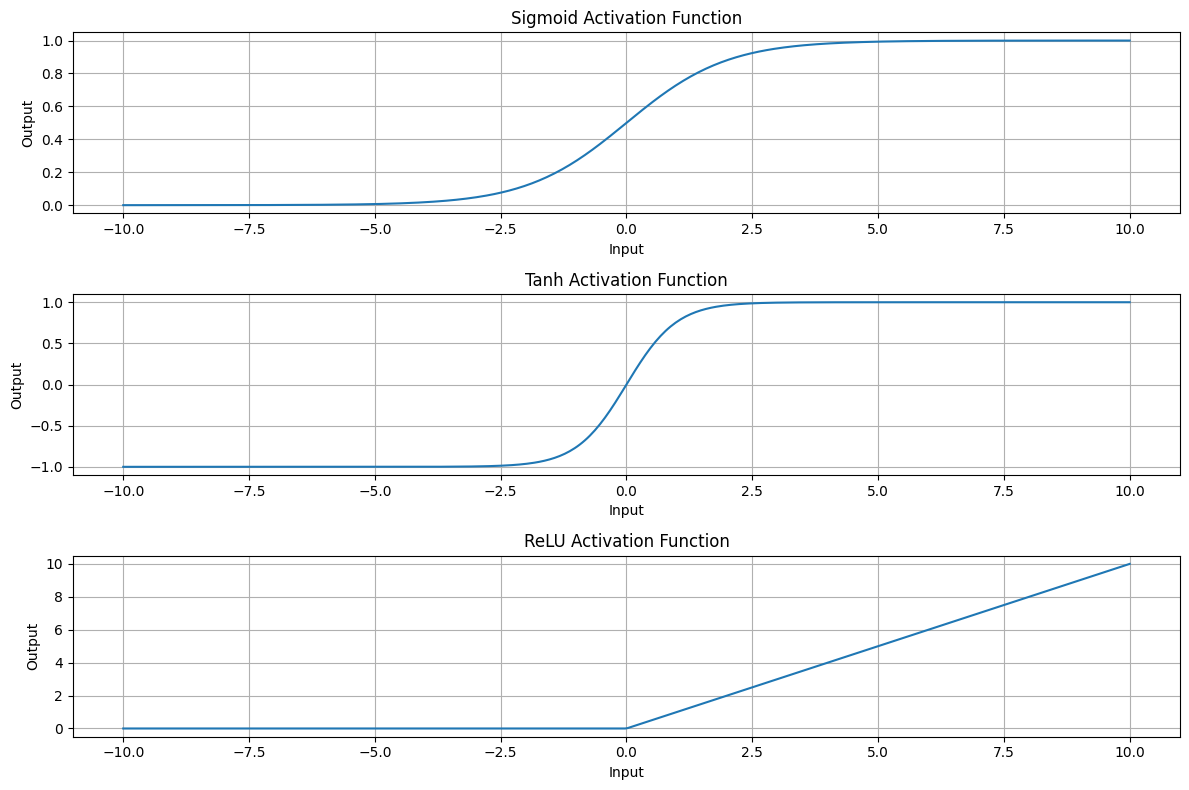

In [1]:
# Deep Learning - Experiment 2
# Task A: Visualization of Activation Functions
# Name: Harshitha
# Roll No: 24BAD034

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)


plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(x, y_sigmoid)
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(x, y_tanh)
plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(x, y_relu)
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.tight_layout()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training with sigmoid activation


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8465 - loss: 0.6555 - val_accuracy: 0.9172 - val_loss: 0.3150
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9163 - loss: 0.3004 - val_accuracy: 0.9310 - val_loss: 0.2466
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9315 - loss: 0.2413 - val_accuracy: 0.9426 - val_loss: 0.2073
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9415 - loss: 0.2036 - val_accuracy: 0.9511 - val_loss: 0.1807
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9485 - loss: 0.1769 - val_accuracy: 0.9544 - val_loss: 0.1645
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9557 - loss: 0.1548 - val_accuracy: 0.9589 - val_loss: 0.1516
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.1377 - val_accuracy: 0.9619 - val_loss: 0.1376
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9649 - loss: 0.1228 - val_accuracy: 0.

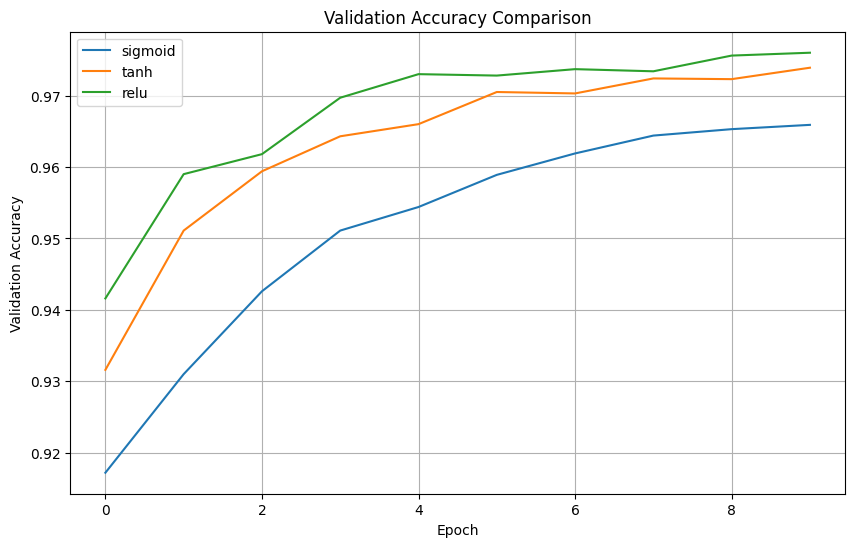

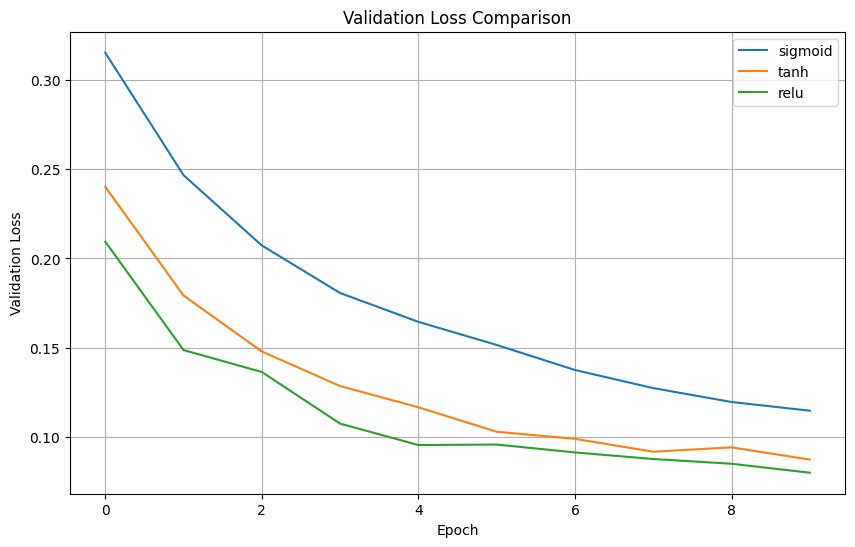

In [2]:
# Deep Learning - Experiment 2
# Task B: Performance Comparison of Activation Functions
# Name: Harshitha
# Roll No: 24BAD034

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist


(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]

def create_model(activation):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

activations = ["sigmoid", "tanh", "relu"]

results = {}
histories = {}

for activation in activations:

    print("\nTraining with", activation, "activation")

    model = create_model(activation)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    results[activation] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Test Accuracy": test_accuracy
    }

    histories[activation] = history

print("\n===== PERFORMANCE COMPARISON =====")

for activation, result in results.items():
    print("\nActivation Function:", activation)
    print("Training Accuracy :", round(result["Training Accuracy"], 4))
    print("Validation Accuracy:", round(result["Validation Accuracy"], 4))
    print("Training Loss     :", round(result["Training Loss"], 4))
    print("Validation Loss   :", round(result["Validation Loss"], 4))
    print("Test Accuracy     :", round(result["Test Accuracy"], 4))

plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["val_accuracy"],
        label=activation
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["val_loss"],
        label=activation
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


Training with SGD
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6904 - loss: 1.3017 - val_accuracy: 0.8600 - val_loss: 0.7045
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 0.6091 - val_accuracy: 0.8867 - val_loss: 0.4752
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8787 - loss: 0.4743 - val_accuracy: 0.8993 - val_loss: 0.3982
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8895 - loss: 0.4163 - val_accuracy: 0.9071 - val_loss: 0.3597
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8963 - loss: 0.3823 - val_accuracy: 0.9106 - val_loss: 0.3355
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - loss: 0.3589 - val_accuracy: 0.9141 - val_loss: 0.3183
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9059 - loss: 0.3412 - val_accuracy: 0.9170 - val_loss: 0.3065
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9102 - loss: 0.3272

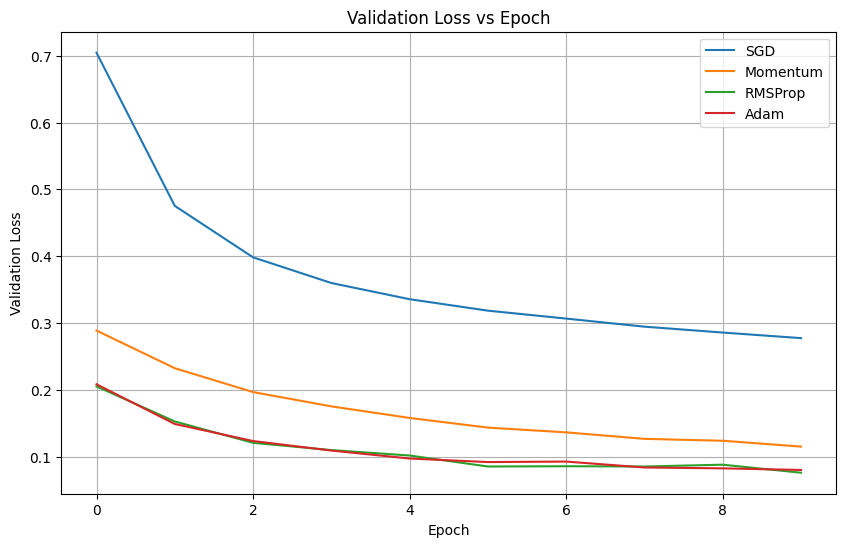

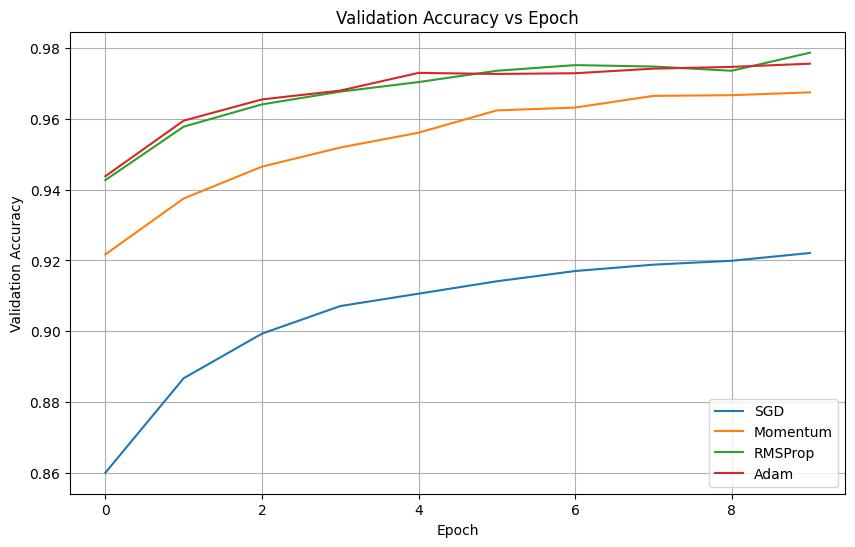

In [3]:
# Deep Learning - Experiment 2
# Task C: Comparison of Optimization Algorithms
# Name: Harshitha
# Roll No: 24BAD034

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]


def create_model(optimizer):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),
    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
}

histories = {}
results = {}


for name, optimizer in optimizers.items():

    print("\nTraining with", name)

    model = create_model(optimizer)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    histories[name] = history

    results[name] = {
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Test Accuracy": test_accuracy
    }



print("\n========== OPTIMIZER COMPARISON ==========")

for name, result in results.items():

    print("\nOptimizer:", name)

    print(
        "Training Loss:",
        round(result["Training Loss"], 4)
    )

    print(
        "Validation Loss:",
        round(result["Validation Loss"], 4)
    )

    print(
        "Training Accuracy:",
        round(result["Training Accuracy"], 4)
    )

    print(
        "Validation Accuracy:",
        round(result["Validation Accuracy"], 4)
    )

    print(
        "Test Accuracy:",
        round(result["Test Accuracy"], 4)
    )




plt.figure(figsize=(10, 6))

for name in optimizers:

    plt.plot(
        histories[name].history["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()




plt.figure(figsize=(10, 6))

for name in optimizers:

    plt.plot(
        histories[name].history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Deep Learning - Experiment 2
# Task D: Deep Learning Experiment Management
# Name: Harshitha
# Roll No: 24BAD034

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

experiment_path = "/content/drive/MyDrive/Deep_Learning_Experiment_2"

os.makedirs(experiment_path, exist_ok=True)

print("Experiment folder created successfully.")
print("Location:", experiment_path)

Experiment folder created successfully.
Location: /content/drive/MyDrive/Deep_Learning_Experiment_2


In [9]:
model_save_path = experiment_path + "/activation_comparison_model.keras"

# Train one final model using a valid optimizer like 'adam' (which uses ReLU internally as defined in Task C)
final_model = create_model("adam")

final_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

final_model.save(model_save_path)

print("Model saved successfully.")
print("Saved at:", model_save_path)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8935 - loss: 0.3856 - val_accuracy: 0.9453 - val_loss: 0.1938
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9488 - loss: 0.1781 - val_accuracy: 0.9610 - val_loss: 0.1384
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9623 - loss: 0.1289 - val_accuracy: 0.9657 - val_loss: 0.1228
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9723 - loss: 0.0992 - val_accuracy: 0.9703 - val_loss: 0.1020
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9771 - loss: 0.0804 - val_accuracy: 0.9708 - val_loss: 0.0992
Model saved successfully.
Saved at: /content/drive/MyDrive/Deep_Learning_Experiment_2/activation_comparison_model.keras
